# CEBRA网络架构实现

基于CEBRA的逻辑，实现对比学习网络来处理神经元数据。

数据格式参考: `train_psth.ipynb`

## 主要内容
- CEBRA模型架构（OffsetModel和Offset10Model）
- InfoNCE损失函数
- 时间对比学习数据加载
- 模型训练和嵌入向量转换


In [1]:
import os
import sys
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from typing import Tuple, Optional
import math

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA设备: {torch.cuda.get_device_name(0)}")


PyTorch版本: 2.8.0+cu128
CUDA可用: True
CUDA设备: NVIDIA GeForce RTX 4070


## 1. CEBRA Layers

定义CEBRA模型所需的基础层：跳跃连接、压缩层和归一化层。


In [2]:
class SkipConnection(nn.Module):
    """带跳跃连接的模块"""
    def __init__(self, *modules, crop=(1, 1)):
        super().__init__()
        self.module = nn.Sequential(*modules)
        self.crop = slice(
            crop[0],
            -crop[1] if isinstance(crop[1], int) and crop[1] > 0 else None
        )

    def forward(self, inp: torch.Tensor) -> torch.Tensor:
        skip = self.module(inp)
        return inp[..., self.crop] + skip


class Squeeze(nn.Module):
    """压缩第3维"""
    def forward(self, inp: torch.Tensor) -> torch.Tensor:
        if inp.dim() > 2:
            return inp.squeeze(2)
        return inp


class Norm(nn.Module):
    """L2归一化层"""
    def forward(self, inp: torch.Tensor) -> torch.Tensor:
        return inp / torch.norm(inp, dim=1, keepdim=True)


## 2. CEBRA Model

定义两种CEBRA模型架构：
- **OffsetModel**: 全连接模型，适用于单时间点数据
- **Offset10Model**: 卷积模型，适用于时间序列数据（感受野为10）


In [3]:
class OffsetModel(nn.Module):
    """CEBRA模型基类 - 单时间点模型（适用于time_bins=10的情况）"""
    
    def __init__(self, num_neurons: int, num_units: int, num_output: int, normalize: bool = True):
        super().__init__()
        if num_units < 2:
            raise ValueError(f"Number of hidden units needs to be at least 2, but got {num_units}.")
        
        layers = [
            nn.Flatten(start_dim=1, end_dim=-1),
            nn.Linear(num_neurons, num_units),
            nn.GELU(),
            nn.Linear(num_units, num_units),
            nn.GELU(),
            nn.Linear(num_units, int(num_units // 2)),
            nn.GELU(),
            nn.Linear(int(num_units // 2), num_output),
        ]
        
        if normalize:
            layers.append(Norm())
        layers.append(Squeeze())
        
        self.net = nn.Sequential(*layers)
        self.num_input = num_neurons
        self.num_output = num_output
        self.normalize = normalize
    
    def forward(self, inp: torch.Tensor) -> torch.Tensor:
        """
        Args:
            inp: 输入张量，形状为 (batch, num_neurons) 或 (batch, num_neurons, 1)
        
        Returns:
            输出嵌入向量，形状为 (batch, num_output)
        """
        return self.net(inp)


class Offset10Model(nn.Module):
    """CEBRA模型 - 10个时间点的感受野（卷积模型）"""
    
    def __init__(self, num_neurons: int, num_units: int, num_output: int, normalize: bool = True):
        super().__init__()
        if num_units < 1:
            raise ValueError(f"Hidden dimension needs to be at least 1, but got {num_units}.")
        
        # 构建卷积层
        layers = [
            nn.Conv1d(num_neurons, num_units, kernel_size=2),
            nn.GELU(),
        ]
        
        # 添加3个残差块
        for _ in range(3):
            layers.append(SkipConnection(
                nn.Conv1d(num_units, num_units, kernel_size=3),
                nn.GELU(),
                crop=(1, 1)
            ))
        
        layers.append(nn.Conv1d(num_units, num_output, kernel_size=3))
        
        if normalize:
            layers.append(Norm())
        layers.append(Squeeze())
        
        self.net = nn.Sequential(*layers)
        self.num_input = num_neurons
        self.num_output = num_output
        self.normalize = normalize
    
    def forward(self, inp: torch.Tensor) -> torch.Tensor:
        """
        Args:
            inp: 输入张量，形状为 (batch, num_neurons, time)
        
        Returns:
            输出嵌入向量，形状为 (batch, num_output, out_time)
        """
        return self.net(inp)


## 3. InfoNCE Loss

实现InfoNCE（Information Noise Contrastive Estimation）损失函数，用于对比学习。


In [4]:
@torch.jit.script
def dot_similarity(ref: torch.Tensor, pos: torch.Tensor, neg: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """计算余弦相似度"""
    pos_dist = torch.einsum("ni,ni->n", ref, pos)
    neg_dist = torch.einsum("ni,mi->nm", ref, neg)
    return pos_dist, neg_dist


@torch.jit.script
def infonce(pos_dist: torch.Tensor, neg_dist: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """InfoNCE损失函数实现"""
    with torch.no_grad():
        c, _ = neg_dist.max(dim=1, keepdim=True)
    c = c.detach()
    
    pos_dist = pos_dist - c.squeeze(1)
    neg_dist = neg_dist - c
    align = (-pos_dist).mean()
    uniform = torch.logsumexp(neg_dist, dim=1).mean()
    
    c_mean = c.mean()
    align_corrected = align - c_mean
    uniform_corrected = uniform + c_mean
    
    return align + uniform, align_corrected, uniform_corrected


class FixedCosineInfoNCE(nn.Module):
    """固定温度的余弦相似度InfoNCE损失"""
    
    def __init__(self, temperature: float = 1.0):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, ref: torch.Tensor, pos: torch.Tensor, neg: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pos_dist, neg_dist = dot_similarity(ref, pos, neg)
        return infonce(pos_dist / self.temperature, neg_dist / self.temperature)


## 4. Dataset

定义数据集类，用于加载和采样神经元数据：
- **NeuralDataset**: 用于单时间点模型
- **NeuralDatasetConv**: 用于卷积模型


In [5]:
class NeuralDataset(Dataset):
    """神经元数据集 - 用于单时间点模型（offset0）"""
    
    def __init__(self, neural_data: np.ndarray, use_time_contrastive: bool = True, time_offset: int = 1):
        """
        Args:
            neural_data: 形状为 (n_trial, time_bins, n_neurons) 的数组
            use_time_contrastive: 是否使用时间对比学习
            time_offset: 正样本的时间偏移量
        """
        self.neural_data = neural_data
        self.n_trial, self.time_bins, self.n_neurons = neural_data.shape
        self.use_time_contrastive = use_time_contrastive
        self.time_offset = time_offset
        
        # 转换为 (total_time, n_neurons) 格式
        # 将所有trials展平，但保留trial信息
        self.total_samples = self.n_trial * self.time_bins
        self.trial_indices = np.repeat(np.arange(self.n_trial), self.time_bins)
        self.time_indices = np.tile(np.arange(self.time_bins), self.n_trial)
    
    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        trial_idx = self.trial_indices[idx]
        time_idx = self.time_indices[idx]
        
        # 获取参考样本: (n_neurons,)
        ref = self.neural_data[trial_idx, time_idx, :].astype(np.float32)
        
        # 获取正样本（同一trial中的相邻时间点）
        if self.use_time_contrastive:
            # 正样本：同一trial，时间偏移为time_offset
            pos_time_idx = min(time_idx + self.time_offset, self.time_bins - 1)
            # 如果时间偏移后超出范围，使用最后一个时间点
            if pos_time_idx == time_idx and time_idx < self.time_bins - 1:
                pos_time_idx = time_idx + 1
            pos = self.neural_data[trial_idx, pos_time_idx, :].astype(np.float32)
        else:
            # 如果没有时间对比，使用相同的样本
            pos = ref.copy()
        
        # 负样本：随机选择另一个trial的随机时间点
        neg_trial_idx = np.random.randint(0, self.n_trial)
        neg_time_idx = np.random.randint(0, self.time_bins)
        neg = self.neural_data[neg_trial_idx, neg_time_idx, :].astype(np.float32)
        
        return {
            'reference': torch.from_numpy(ref),
            'positive': torch.from_numpy(pos),
            'negative': torch.from_numpy(neg)
        }


class NeuralDatasetConv(Dataset):
    """神经元数据集 - 用于卷积模型（offset10），处理时间序列"""
    
    def __init__(self, neural_data: np.ndarray, use_time_contrastive: bool = True, time_offset: int = 1):
        """
        Args:
            neural_data: 形状为 (n_trial, time_bins, n_neurons) 的数组
            use_time_contrastive: 是否使用时间对比学习
            time_offset: 正样本的时间偏移量
        """
        self.neural_data = neural_data
        self.n_trial, self.time_bins, self.n_neurons = neural_data.shape
        self.use_time_contrastive = use_time_contrastive
        self.time_offset = time_offset
        
        # 对于卷积模型，每个trial作为一个样本
        self.total_samples = self.n_trial
    
    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        # 获取整个trial: (time_bins, n_neurons) -> 转置为 (n_neurons, time_bins) 用于卷积
        ref_trial = self.neural_data[idx].astype(np.float32).T  # (n_neurons, time_bins)
        
        # 正样本：同一trial（时间对比学习）
        pos_trial = ref_trial.copy()
        
        # 负样本：随机选择另一个trial
        neg_trial_idx = np.random.randint(0, self.n_trial)
        neg_trial = self.neural_data[neg_trial_idx].astype(np.float32).T  # (n_neurons, time_bins)
        
        return {
            'reference': torch.from_numpy(ref_trial),
            'positive': torch.from_numpy(pos_trial),
            'negative': torch.from_numpy(neg_trial)
        }


## 5. Training Function

定义训练函数，用于训练CEBRA模型。


In [6]:
def train_cebra(
    neural_data: np.ndarray,
    model_type: str = "offset0",  # "offset0" 或 "offset10"
    num_units: int = 32,
    num_output: int = 8,
    normalize: bool = True,
    temperature: float = 1.0,
    batch_size: int = 512,
    learning_rate: float = 3e-4,
    num_epochs: int = 100,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    save_dir: str = "data/cebra_psth",
    use_time_contrastive: bool = True,
    time_offset: int = 1
):
    """
    训练CEBRA模型
    
    Args:
        neural_data: 形状为 (n_trial, time_bins, n_neurons) 的数组
        model_type: 模型类型，"offset0" 或 "offset10"
        num_units: 隐藏层单元数
        num_output: 输出维度
        normalize: 是否归一化输出
        temperature: InfoNCE温度参数
        batch_size: 批次大小
        learning_rate: 学习率
        num_epochs: 训练轮数
        device: 设备
        save_dir: 保存目录
        use_time_contrastive: 是否使用时间对比学习
        time_offset: 正样本时间偏移
    """
    print(f"使用设备: {device}")
    print(f"数据形状: {neural_data.shape}")
    
    n_trial, time_bins, n_neurons = neural_data.shape
    print(f"Trials: {n_trial}, 时间bins: {time_bins}, 神经元数: {n_neurons}")
    
    # 创建数据集
    if model_type == "offset10" and time_bins >= 10:
        dataset = NeuralDatasetConv(neural_data, use_time_contrastive=use_time_contrastive, time_offset=time_offset)
    else:
        dataset = NeuralDataset(neural_data, use_time_contrastive=use_time_contrastive, time_offset=time_offset)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    
    # 创建模型
    if model_type == "offset0":
        # 单时间点模型（全连接）
        model = OffsetModel(n_neurons, num_units, num_output, normalize=normalize)
        print(f"使用 Offset0Model (全连接模型)")
    elif model_type == "offset10":
        # 卷积模型（需要time_bins >= 10）
        if time_bins < 10:
            print(f"警告: time_bins={time_bins} < 10，改用offset0模型")
            model = OffsetModel(n_neurons, num_units, num_output, normalize=normalize)
        else:
            model = Offset10Model(n_neurons, num_units, num_output, normalize=normalize)
            print(f"使用 Offset10Model (卷积模型)")
    else:
        raise ValueError(f"未知的模型类型: {model_type}")
    
    model = model.to(device)
    
    # 创建损失函数和优化器
    criterion = FixedCosineInfoNCE(temperature=temperature).to(device)
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(criterion.parameters()),
        lr=learning_rate
    )
    
    # 训练循环
    print(f"\n开始训练，共 {num_epochs} 个epoch...")
    model.train()
    history = {'loss': [], 'align': [], 'uniform': []}
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_align = 0.0
        epoch_uniform = 0.0
        num_batches = 0
        
        for batch in dataloader:
            ref = batch['reference'].to(device)
            pos = batch['positive'].to(device)
            neg = batch['negative'].to(device)
            
            # 前向传播
            ref_emb = model(ref)
            pos_emb = model(pos)
            neg_emb = model(neg)
            
            # 计算损失
            loss, align, uniform = criterion(ref_emb, pos_emb, neg_emb)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_align += align.item()
            epoch_uniform += uniform.item()
            num_batches += 1
        
        avg_loss = epoch_loss / num_batches
        avg_align = epoch_align / num_batches
        avg_uniform = epoch_uniform / num_batches
        
        history['loss'].append(avg_loss)
        history['align'].append(avg_align)
        history['uniform'].append(avg_uniform)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Align: {avg_align:.4f}, Uniform: {avg_uniform:.4f}")
    
    # 保存模型
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)
    
    model_path = save_path / "cebra_model.pth"
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'model_type': model_type,
        'num_neurons': n_neurons,
        'num_units': num_units,
        'num_output': num_output,
        'normalize': normalize,
    }, model_path)
    print(f"\n模型已保存到: {model_path}")
    
    return model, history


## 6. Transform Function

定义数据转换函数，使用训练好的模型将神经元数据转换为嵌入向量。


In [7]:
def transform_data(
    model: nn.Module,
    neural_data: np.ndarray,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    batch_size: int = 512
) -> np.ndarray:
    """
    使用训练好的模型转换数据
    
    Args:
        model: 训练好的CEBRA模型
        neural_data: 形状为 (n_trial, time_bins, n_neurons) 的数组
        device: 设备
        batch_size: 批次大小
    
    Returns:
        嵌入向量，形状为 (n_trial, time_bins, num_output) 或 (n_trial * time_bins, num_output)
    """
    model.eval()
    n_trial, time_bins, n_neurons = neural_data.shape
    
    embeddings = []
    
    with torch.no_grad():
        # 按trial处理
        for trial_idx in range(n_trial):
            trial_data = neural_data[trial_idx]  # (time_bins, n_neurons)
            trial_tensor = torch.from_numpy(trial_data.astype(np.float32)).to(device)
            
            # 如果是卷积模型，需要转换为 (1, n_neurons, time_bins)
            if isinstance(model, Offset10Model):
                trial_tensor = trial_tensor.T.unsqueeze(0)  # (1, n_neurons, time_bins)
                emb = model(trial_tensor)  # (1, num_output, out_time)
                emb = emb.squeeze(0).T  # (out_time, num_output)
            else:
                # 全连接模型，逐时间点处理
                emb = model(trial_tensor)  # (time_bins, num_output)
            
            embeddings.append(emb.cpu().numpy())
    
    return np.array(embeddings)


## 7. 加载数据

加载PSTH数据和相关的trial image IDs。


In [8]:
# 设置数据路径（根据实际情况修改）
psth_data_path = "/home/ubuntu/Desktop/psth_matrix_raw.npy"
image_id_path = "/home/ubuntu/Desktop/trial_image_id.pkl"

# 加载数据
print("加载数据...")
psth_matrix = np.load(psth_data_path)  # (n_trial, time_bins, n_neurons)
trial_image_ids = pickle.load(open(image_id_path, "rb"))

print(f"数据形状: {psth_matrix.shape}")
print(f"Image IDs数量: {len(trial_image_ids)}")
print(f"唯一的Image IDs数量: {len(set(trial_image_ids))}")

# 数据预处理：归一化（可选）
# psth_matrix = (psth_matrix - psth_matrix.mean(axis=(0, 1), keepdims=True)) / (psth_matrix.std(axis=(0, 1), keepdims=True) + 1e-8)


加载数据...
数据形状: (2360, 10, 84)
Image IDs数量: 2360
唯一的Image IDs数量: 118


## 8. 训练模型

使用CEBRA模型训练，学习神经元数据的低维嵌入表示。


In [10]:
# 训练模型
print("="*50)
print("开始训练CEBRA模型")
print("="*50)

model, history = train_cebra(
    neural_data=psth_matrix,
    model_type="offset10",  # 因为time_bins=10，可以用offset0或offset10
    num_units=32,
    num_output=8,
    normalize=True,
    temperature=1.0,
    batch_size=512,
    learning_rate=3e-4,
    num_epochs=100,
    use_time_contrastive=True,
    time_offset=1,
    save_dir="data/cebra_psth"
)


开始训练CEBRA模型
使用设备: cuda
数据形状: (2360, 10, 84)
Trials: 2360, 时间bins: 10, 神经元数: 84
使用 Offset10Model (卷积模型)

开始训练，共 100 个epoch...
Epoch [1/100] - Loss: 6.0955, Align: -1.0000, Uniform: 7.0955
Epoch [10/100] - Loss: 5.2520, Align: -1.0000, Uniform: 6.2520
Epoch [20/100] - Loss: 5.2178, Align: -1.0000, Uniform: 6.2178
Epoch [30/100] - Loss: 5.2107, Align: -1.0000, Uniform: 6.2107
Epoch [40/100] - Loss: 5.2093, Align: -1.0000, Uniform: 6.2093
Epoch [50/100] - Loss: 5.2061, Align: -1.0000, Uniform: 6.2061
Epoch [60/100] - Loss: 5.2040, Align: -1.0000, Uniform: 6.2040
Epoch [70/100] - Loss: 5.2047, Align: -1.0000, Uniform: 6.2047
Epoch [80/100] - Loss: 5.2043, Align: -1.0000, Uniform: 6.2043
Epoch [90/100] - Loss: 5.2038, Align: -1.0000, Uniform: 6.2038
Epoch [100/100] - Loss: 5.2041, Align: -1.0000, Uniform: 6.2041

模型已保存到: data/cebra_psth/cebra_model.pth


## 9. 转换数据为嵌入向量

使用训练好的模型将原始神经元数据转换为低维嵌入向量。


In [11]:
# 转换数据
print("="*50)
print("转换数据为嵌入向量")
print("="*50)

embeddings = transform_data(model, psth_matrix)
print(f"嵌入向量形状: {embeddings.shape}")


转换数据为嵌入向量


/tmp/ipykernel_48532/2179172452.py:34: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  emb = emb.squeeze(0).T  # (out_time, num_output)


嵌入向量形状: (2360, 8)


## 10. 保存结果

保存训练好的嵌入向量和相关数据。


In [ ]:
# 保存结果
output_file = "data/cebra_embeddings_psth.pkl"
results = {
    'embeddings': embeddings,
    'neural_data': psth_matrix,
    'trial_image_ids': trial_image_ids,
    'history': history,
    'model_type': 'offset0',
    'num_output': 8
}

with open(output_file, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"\n结果已保存到: {output_file}")
print("训练完成!")


## 11. 可视化训练历史（可选）

绘制训练过程中的损失曲线。


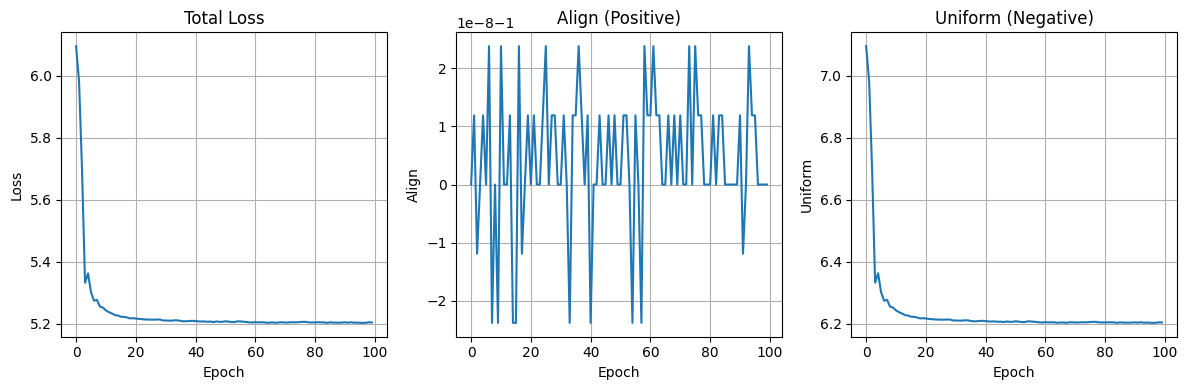

In [ ]:
import matplotlib.pyplot as plt

# 绘制训练历史
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history['loss'])
plt.title('Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history['align'])
plt.title('Align (Positive)')
plt.xlabel('Epoch')
plt.ylabel('Align')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history['uniform'])
plt.title('Uniform (Negative)')
plt.xlabel('Epoch')
plt.ylabel('Uniform')
plt.grid(True)

plt.tight_layout()
plt.show()
